In [ ]:
import os
import pandas as pd

# Collegamento drive
from google.colab import drive
drive.mount('/content/drive')

# Definizione percorso
path = '/content/drive/My Drive/Tesi_dataset3'

# Lista di tutti i file che iniziano con 'Aida_Export'
all_files = [os.path.join(path, f) for f in os.listdir(path) if f.startswith('Aida_Export')]
all_files.sort()

df_list = []

print(f"Inizio caricamento di {len(all_files)} file...")

for filename in all_files:
    # Leggiamo il file
    data = pd.read_excel(filename)

    # Pulizia righe vuote basata sulla colonna 'Tax code number'
    if 'Tax code number' in data.columns:
        data = data.dropna(subset=['Tax code number'])

    # Rimuoviamo righe totalmente vuote
    data = data.dropna(how='all')

    print(f"Caricato correttamente: {os.path.basename(filename)} | Righe: {len(data)}")
    df_list.append(data)

# Unione di tutti i file in un unico DataFrame
df = pd.concat(df_list, ignore_index=True)

# Rimozione duplicati
if 'Tax code number' in df.columns:
    df = df.drop_duplicates(subset=['Tax code number'], keep='first')

print(f"Aziende totali caricate: {len(df)}")
print(f"Colonne totali: {len(df.columns)}")

# Imposta Pandas per mostrare tutte le colonne
pd.set_option('display.max_columns', None)

# Mostriamo le prime 5 righe
df.head()

Mounted at /content/drive
Inizio caricamento di 2 file...
Caricato correttamente: Aida_Export_1c.xlsx | Righe: 28571
Caricato correttamente: Aida_Export_2c.xlsx | Righe: 15816
Aziende totali caricate: 44387
Colonne totali: 41


,Unnamed: 0,Company name,Tax code number,Registered office address - Region,Legal form,Legal status,Date of open procedure/cessazione,Procedure/cessazione,ATECO 2007\ncode,ATECO 2007\ndescription,TOTAL ASSETS\nth EUR\n2021,TOTAL ASSETS\nth EUR\n2020,TOTAL ASSETS\nth EUR\n2019,Current liabilities/Tot ass.\n%\n2021,Current liabilities/Tot ass.\n%\n2020,Current liabilities/Tot ass.\n%\n2019,Solvency ratio (%)\n%\n2021,Solvency ratio (%)\n%\n2020,Solvency ratio (%)\n%\n2019,Debt/EBITDA ratio\n%\n2021,Debt/EBITDA ratio\n%\n2020,Debt/EBITDA ratio\n%\n2019,Total assets turnover (times)\n2021,Total assets turnover (times)\n2020,Total assets turnover (times)\n2019,Current ratio\n2020,Current ratio\n2021,Current ratio\n2019,Return on asset (ROA)\n%\n2021,Return on asset (ROA)\n%\n2020,Return on asset (ROA)\n%\n2019,Durata media dei crediti al lordo IVA (days)\nLast avail. yr,Durata media dei crediti al lordo IVA (days)\n2021,Durata media dei crediti al lordo IVA (days)\n2020,Durata media dei crediti al lordo IVA (days)\n2019,BvD Independence Indicator\n2021,No of shareholders\n2021,BvD Independence Indicator\n2020,No of shareholders\n2020,BvD Independence Indicator\n2019,No of shareholders\n2019
0,1.0,GESTORE DEI MERCATI ENERGETICI S.P.A.,6208031002,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,4444630,746145.0,827195,1,0.99,0.98,0.63,3.88,3,17.18,3.39,4.11,n.s.,n.s.,n.s.,1.04,1,1.04,0.25,1.67,1.12,30.36,26.76,12.4,10.23,D,1,D,1,D,1
1,2.0,ENI S.P.A.,484960588,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,115619962,86015427.0,83295729,0.44,0.36,0.45,44.14,51.98,49.99,3.5,-4.86,18.27,0.33,0.21,0.34,1.95,2.54,1.59,0.49,-4.64,-2.45,64.28,62.49,25.28,20.74,B+,3,B+,8,B+,8
2,3.0,ENEL ENERGIA S.P.A.,6655971007,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,6068014,4459369.0,4796219,1,1,1,22.07,28.33,28.89,0.07,0.09,0.12,2.49,2.92,2.88,1.17,1.1,1.23,21.78,29.44,29.88,24.79,48.23,41.06,35.85,D,2,D,2,D,1
3,4.0,STELLANTIS EUROPE S.P.A.,7973780013,Piemonte,Joint stock company - SPA,Active,NaT,NaN,291000,Manufacture of motor vehicles,21256773,23759070.0,19378194,0.84,0.52,0.96,29.37,32.65,50.1,28.67,-7.13,4,1.03,0.84,1.26,1.75,1.04,1.09,-5.57,-7.19,-4.87,8,0.68,2.01,2.25,C,1,C,1,C,1
4,5.0,KUWAIT PETROLEUM ITALIA S.P.A.,435970587,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,3386429,2823987.0,2575102,0.93,0.86,0.91,16.29,16.71,17.95,1.04,-5.31,-6.05,3.72,2.82,4.34,0.75,0.82,0.7,4.77,-4.69,-6.1,15.48,20.01,18.18,8.33,D,1,D,1,D,1


In [ ]:
# Rimozione della colonna inutile
df = df.drop(columns=['Durata media dei crediti al lordo IVA (days)\nLast avail. yr'])

In [ ]:
print(df['Legal status'].value_counts())

Legal status
Active                     43055
In liquidation               896
Bankruptcy                   349
Dissolved (liquidation)       83
Dissolved (bankruptcy)         4
Name: count, dtype: int64


In [ ]:
import numpy as np
import re

# Creazione variabile Target (0 = Sana, 1 = Default)
df['Target'] = df['Legal status'].apply(lambda x: 0 if x == 'Active' else 1)

# Funzione per pulire i nomi delle colonne
def clean_col(name):
    # Rimuove unità di misura e simboli
    name = name.replace('th EUR', '').replace('EUR', '').replace('%', '').replace('(%)', '').replace('\'', ' ').replace('()','')
    # Sostituisce spazi e "a capo" con underscore
    name = re.sub(r'\s+', '_', name).strip('_')
    return name

df.columns = [clean_col(c) for c in df.columns]

print(f"Aziende Sane (0): {len(df[df['Target']==0])}")
print(f"Aziende in Default (1): {len(df[df['Target']==1])}")

# Mostriamo le prime 5 righe
df.head()

Aziende Sane (0): 43055
Aziende in Default (1): 1332


,Unnamed:_0,Company_name,Tax_code_number,Registered_office_address_-_Region,Legal_form,Legal_status,Date_of_open_procedure/cessazione,Procedure/cessazione,ATECO_2007_code,ATECO_2007_description,TOTAL_ASSETS_2021,TOTAL_ASSETS_2020,TOTAL_ASSETS_2019,Current_liabilities/Tot_ass._2021,Current_liabilities/Tot_ass._2020,Current_liabilities/Tot_ass._2019,Solvency_ratio_2021,Solvency_ratio_2020,Solvency_ratio_2019,Debt/EBITDA_ratio_2021,Debt/EBITDA_ratio_2020,Debt/EBITDA_ratio_2019,Total_assets_turnover_(times)_2021,Total_assets_turnover_(times)_2020,Total_assets_turnover_(times)_2019,Current_ratio_2020,Current_ratio_2021,Current_ratio_2019,Return_on_asset_(ROA)_2021,Return_on_asset_(ROA)_2020,Return_on_asset_(ROA)_2019,Durata_media_dei_crediti_al_lordo_IVA_(days)_2021,Durata_media_dei_crediti_al_lordo_IVA_(days)_2020,Durata_media_dei_crediti_al_lordo_IVA_(days)_2019,BvD_Independence_Indicator_2021,No_of_shareholders_2021,BvD_Independence_Indicator_2020,No_of_shareholders_2020,BvD_Independence_Indicator_2019,No_of_shareholders_2019,Target
0,1.0,GESTORE DEI MERCATI ENERGETICI S.P.A.,6208031002,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,4444630,746145.0,827195,1,0.99,0.98,0.63,3.88,3,17.18,3.39,4.11,n.s.,n.s.,n.s.,1.04,1,1.04,0.25,1.67,1.12,26.76,12.4,10.23,D,1,D,1,D,1,0
1,2.0,ENI S.P.A.,484960588,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,115619962,86015427.0,83295729,0.44,0.36,0.45,44.14,51.98,49.99,3.5,-4.86,18.27,0.33,0.21,0.34,1.95,2.54,1.59,0.49,-4.64,-2.45,62.49,25.28,20.74,B+,3,B+,8,B+,8,0
2,3.0,ENEL ENERGIA S.P.A.,6655971007,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,6068014,4459369.0,4796219,1,1,1,22.07,28.33,28.89,0.07,0.09,0.12,2.49,2.92,2.88,1.17,1.1,1.23,21.78,29.44,29.88,48.23,41.06,35.85,D,2,D,2,D,1,0
3,4.0,STELLANTIS EUROPE S.P.A.,7973780013,Piemonte,Joint stock company - SPA,Active,NaT,NaN,291000,Manufacture of motor vehicles,21256773,23759070.0,19378194,0.84,0.52,0.96,29.37,32.65,50.1,28.67,-7.13,4,1.03,0.84,1.26,1.75,1.04,1.09,-5.57,-7.19,-4.87,0.68,2.01,2.25,C,1,C,1,C,1,0
4,5.0,KUWAIT PETROLEUM ITALIA S.P.A.,435970587,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,3386429,2823987.0,2575102,0.93,0.86,0.91,16.29,16.71,17.95,1.04,-5.31,-6.05,3.72,2.82,4.34,0.75,0.82,0.7,4.77,-4.69,-6.1,20.01,18.18,8.33,D,1,D,1,D,1,0


In [ ]:
# CONFIGURAZIONE NOMI COLONNE E WHITE LIST EVENTI DEFAULT

prefissi_finance = [
    'TOTAL_ASSETS', 'Current_liabilities/Tot_ass.', 'Solvency_ratio', 'Debt/EBITDA_ratio',
    'Total_assets_turnover_(times)', 'Durata_media_dei_crediti_al_lordo_IVA_(days)',
    'Return_on_asset_(ROA)', 'Current_ratio', 'BvD_Independence_Indicator', 'No_of_shareholders'
]

prefissi_finance_clean = [clean_col(p) for p in prefissi_finance]
col_data_procedura = clean_col('Date of open procedure/cessazione')
col_tipo_procedura = clean_col('Procedure/cessazione')

# Lista definitiva e completa dei default reali (Estratta dalla lista eventi completa di AIDA)
eventi_default = [
    'Bankruptcy',
    'Judicial liquidation',
    'Composition with creditors',
    'Simplified composition with creditors',
    'Court ordered administration',
    'Court ordered liquidation',
    'Creditors agreement',
    'Debt restructuring agreements',
    'Closure due to bankruptcy or liquidatione',   # Errore di battitura originale di Aida mantenuto
    'Conclusion of bankruptcy procedures',
    'Conclusion of liquidation',
    'Controlled winding-up',
    'Unified procedure',
    'Winding up',
    'Winding up and liquidation',
    'Winding up by official order',
    'In liquidation'                               # Mantenuta per intercettare lo stato del Legal Status
]

# FUNZIONE CONVERSIONE DATA EXCEL
def converti_data_excel(valore):
    if pd.isna(valore):
        return pd.NaT
    valore_str = str(valore).strip()
    if isinstance(valore, (int, float)) or valore_str.replace('.', '', 1).isdigit():
        try:
            return pd.to_datetime(float(valore_str), unit='D', origin='1899-12-30')
        except:
            return pd.NaT
    else:
        return pd.to_datetime(valore, errors='coerce')

df[col_data_procedura] = df[col_data_procedura].apply(converti_data_excel)

# CALCOLO DELL'ANNO t-3 PER I SOLI DEFAULT REALI FILTRATI

def calcola_t3_con_evento(row):
    if row['Target'] == 1:
        # Recuperiamo il tipo di procedura descrittiva
        tipo_evento = str(row[col_tipo_procedura]).strip()

        # CONTROLLO A: L'evento fa parte della nostra White List di default reali?
        if any(evento in tipo_evento for evento in eventi_default) or str(row['Legal_status']) in ['In liquidation', 'Bankruptcy']:

            # CONTROLLO B: C'è una data valida per calcolare lo sfasamento?
            if pd.notna(row[col_data_procedura]) and row[col_data_procedura] is not pd.NaT:
                anno_default = row[col_data_procedura].year

                if anno_default == 1970:
                    return np.nan

                anno_t3 = anno_default - 3

                # Blocco impostato: accettiamo solo anni di riferimento 2019, 2020, 2021
                if 2019 <= anno_t3 <= 2021:
                    return anno_t3
    return np.nan

df['Anno_Riferimento'] = df.apply(calcola_t3_con_evento, axis=1)

# Accoppiamento proporzionale delle aziende sane (solo 2019, 2020, 2021)
distribuzione_fallite = df[df['Target'] == 1]['Anno_Riferimento'].dropna().value_counts(normalize=True)

if not distribuzione_fallite.empty:
    anni_disponibili = distribuzione_fallite.index.astype(int).tolist()
    probabilita = distribuzione_fallite.values.tolist()

    num_sane = len(df[df['Target'] == 0])

    # Campionamento stratificato per le sane basato sulle frequenze delle fallite filtrate
    np.random.seed(42)  # Replicabilità scientifica
    anni_assegnati_sane = np.random.choice(anni_disponibili, size=num_sane, p=probabilita)

    df.loc[df['Target'] == 0, 'Anno_Riferimento'] = anni_assegnati_sane
else:
    raise ValueError("Errore: nessuna azienda in default ha un evento valido associato a una data compresa tra il 2019 e il 2021.")

# Sfoltiamo il dataset: eliminiamo solo i default (Target 1) non qualificati o fuori range temporale
# Le aziende sane vengono tutte preservate intatte senza alcuna perdita
df = df[~((df['Target'] == 1) & (df['Anno_Riferimento'].isna()))]

# Convertiamo l'anno di riferimento in intero puro
df['Anno_Riferimento'] = df['Anno_Riferimento'].astype(int)

print("=== DISTRIBUZIONE ANNO RIFERIMENTO CONSOLIDATO (t-3) ===")
print(df.groupby('Target')['Anno_Riferimento'].value_counts(dropna=False).unstack(level=0))

# Estrazione conservativa dei valori a t-3 (preserva i NaN)
def estrai_valore_t3(row, prefisso):
    anno = row['Anno_Riferimento']
    if pd.isna(anno):
        return np.nan

    stringa_cercata = f"{prefisso}_{int(anno)}"
    if stringa_cercata in df.columns:
        return row[stringa_cercata]

    colonne_candidate = [c for c in df.columns if prefisso in c and str(int(anno)) in c]
    if colonne_candidate:
        return row[colonne_candidate[0]]

    # Se il dato manca in quell'anno specifico, restituisce NaN (fondamentale per la successiva mediana)
    return np.nan

# Creazione delle colonne aggregate a t-3
for prefisso in prefissi_finance_clean:
    nome_nuova_colonna = f"{prefisso}_t3"
    df[nome_nuova_colonna] = df.apply(lambda r: estrai_valore_t3(r, prefisso), axis=1)

# Rimozione colonne annuali (PULIZIA CROSS-SECTION FINALE)
# Eliminiamo le vecchie colonne annuali (2015-2026), lasciando solo quelle con suffisso _t3 e l'Anno_Riferimento
colonne_da_rimuovere = [c for c in df.columns if any(str(anno) in c for anno in range(2015, 2027)) and c != 'Anno_Riferimento' and not c.endswith('_t3')]
df_pulito = df.drop(columns=colonne_da_rimuovere)

print("\n=== SINTESI DATASET CROSS-SECTION CONCLUSO ===")
print(f"Colonne annuali rimosse dal vecchio blocco: {len(colonne_da_rimuovere)}")
print(f"Struttura finale della matrice dei dati: {df_pulito.shape} (Righe, Colonne)")
print(f"Conteggio finale bilanciato del Target:\n{df_pulito['Target'].value_counts()}")

# Mostriamo le prime righe del dataset finale pronto per l'imputazione e le dummy
df_pulito.head()

=== DISTRIBUZIONE ANNO RIFERIMENTO CONSOLIDATO (t-3) ===
Target                0    1
Anno_Riferimento            
2019               6123   92
2020              15298  229
2021              21634  324

=== SINTESI DATASET CROSS-SECTION CONCLUSO ===
Colonne annuali rimosse dal vecchio blocco: 30
Struttura finale della matrice dei dati: (43700, 22) (Righe, Colonne)
Conteggio finale bilanciato del Target:
Target
0    43055
1      645
Name: count, dtype: int64


,Unnamed:_0,Company_name,Tax_code_number,Registered_office_address_-_Region,Legal_form,Legal_status,Date_of_open_procedure/cessazione,Procedure/cessazione,ATECO_2007_code,ATECO_2007_description,Target,Anno_Riferimento,TOTAL_ASSETS_t3,Current_liabilities/Tot_ass._t3,Solvency_ratio_t3,Debt/EBITDA_ratio_t3,Total_assets_turnover_(times)_t3,Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,Return_on_asset_(ROA)_t3,Current_ratio_t3,BvD_Independence_Indicator_t3,No_of_shareholders_t3
0,1.0,GESTORE DEI MERCATI ENERGETICI S.P.A.,6208031002,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,0,2021,4444630,1,0.63,17.18,n.s.,26.76,0.25,1,D,1
1,2.0,ENI S.P.A.,484960588,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,0,2019,83295729,0.45,49.99,18.27,0.34,20.74,-2.45,1.59,B+,8
2,3.0,ENEL ENERGIA S.P.A.,6655971007,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,0,2020,4459369.0,1,28.33,0.09,2.92,41.06,29.44,1.17,D,2
3,4.0,STELLANTIS EUROPE S.P.A.,7973780013,Piemonte,Joint stock company - SPA,Active,NaT,NaN,291000,Manufacture of motor vehicles,0,2020,23759070.0,0.52,32.65,-7.13,0.84,2.01,-7.19,1.75,C,1
4,5.0,KUWAIT PETROLEUM ITALIA S.P.A.,435970587,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,0,2021,3386429,0.93,16.29,1.04,3.72,20.01,4.77,0.82,D,1


In [ ]:
# ENCODING GEOGRAFICO

# Dizionario di mappatura
region_mapping = {
    "Valle d'Aosta/Vallée d'Aoste": 'North', 'Piemonte': 'North', 'Liguria': 'North',
    'Lombardia': 'North', 'Trentino-Alto Adige/Südtirol': 'North', 'Veneto': 'North',
    'Friuli-Venezia Giulia': 'North', 'Emilia-Romagna': 'North',
    'Toscana': 'Center', 'Umbria': 'Center', 'Marche': 'Center', 'Lazio': 'Center',
    'Abruzzo': 'South', 'Molise': 'South', 'Campania': 'South', 'Puglia': 'South',
    'Basilicata': 'South', 'Calabria': 'South', 'Sicilia': 'South', 'Sardegna': 'South'
}

# Pulizia preventiva per evitare duplicazioni
colonne_geo = ['Areas', 'Area_North', 'Area_Center', 'Area_South']
df_pulito = df_pulito.drop(columns=[col for col in colonne_geo if col in df_pulito.columns], errors='ignore')

# Applicazione della mappatura temporanea sulla colonna originale inglese
df_pulito['Areas'] = df_pulito['Registered_office_address_-_Region'].astype(str).str.strip().map(region_mapping)

# Intervento manuale per Kellogg Italia S.p.A. (Sede a Milano -> North)
df_pulito.loc[df_pulito['Company_name'].str.contains('KELLOGG', case=False, na=False), 'Areas'] = 'North'

# Generazione ed encoding forzato delle dummy geografiche
df_areas_dummies = pd.get_dummies(df_pulito['Areas'], prefix='Area', dtype=int)
df_pulito['Area_North'] = df_areas_dummies['Area_North'].values
df_pulito['Area_Center'] = df_areas_dummies['Area_Center'].values
df_pulito['Area_South'] = df_areas_dummies['Area_South'].values

# Rimuoviamo definitivamente la colonna testuale 'Areas'
df_pulito = df_pulito.drop(columns=['Areas'], errors='ignore')

# Rimuoviamo le vecchie annate quantitative grezze se presenti
colonne_vecchie_anni = [col for col in df_pulito.columns if '2019' in col or '2020' in col or '2021' in col]
df_pulito = df_pulito.drop(columns=colonne_vecchie_anni, errors='ignore')


# GOVERNANCE - PULIZIA ED ENCODING INDICE DI INDIPENDENZA BvD

# Pulizia testuale preliminare
df_pulito['BvD_Independence_Indicator_t3'] = df_pulito['BvD_Independence_Indicator_t3'].astype(str).str.strip()
df_pulito['BvD_Independence_Indicator_t3'] = df_pulito['BvD_Independence_Indicator_t3'].replace(['', 'nan', 'None', '-', 'n.a.', 'U'], 'Missing')

# Funzione per prendere la prima lettera (Raggruppa A+, B-, ecc. e preserva 'Missing')
def isola_macro_voto(x):
    if x == 'Missing':
        return 'Missing'
    return str(x)[0]

df_pulito['BvD_Independence_Indicator_t3'] = df_pulito['BvD_Independence_Indicator_t3'].apply(isola_macro_voto)

# Pulizia preventiva vecchie colonne indipendenza per evitare duplicati in caso di esecuzioni ripetute
colonne_indep_vecchie = [c for c in df_pulito.columns if 'Independence_t3_' in c]
df_pulito = df_pulito.drop(columns=colonne_indep_vecchie, errors='ignore')

# One-Hot Encoding dell'indice di indipendenza
df_pulito = pd.get_dummies(df_pulito, columns=['BvD_Independence_Indicator_t3'], prefix='Independence_t3', prefix_sep='_', dtype=int)


# VERIFICA FINALE E VISUALIZZAZIONE COMPLETA DI TUTTE LE DUMMY
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=== VERIFICA CAMPIONE DOPO NUOVO ONE-HOT ENCODING ===")
print(df_pulito['Target'].value_counts())

print("\nNuove colonne dummy di Governance create:")
print([c for c in df_pulito.columns if 'Independence_t3_' in c])

print("\nColonne dummy Geografiche presenti:")
print(['Area_North', 'Area_Center', 'Area_South'])
print("-" * 80)
print("=== ANTEPRIMA DELLE RIGHE FOCUS (GEOGRAFIA + GOVERNANCE) ===")

# Selezioniamo le colonne chiave, escludendo Areas
colonne_da_mostrare = ['Company_name', 'Area_North', 'Area_Center', 'Area_South'] + [c for c in df_pulito.columns if 'Independence_t3_' in c]
display(df_pulito[colonne_da_mostrare].head())

=== VERIFICA CAMPIONE DOPO NUOVO ONE-HOT ENCODING ===
Target
0    43055
1      645
Name: count, dtype: int64

Nuove colonne dummy di Governance create:
['Independence_t3_A', 'Independence_t3_B', 'Independence_t3_C', 'Independence_t3_D', 'Independence_t3_Missing']

Colonne dummy Geografiche presenti:
['Area_North', 'Area_Center', 'Area_South']
--------------------------------------------------------------------------------
=== ANTEPRIMA DELLE RIGHE FOCUS (GEOGRAFIA + GOVERNANCE) ===


,Company_name,Area_North,Area_Center,Area_South,Independence_t3_A,Independence_t3_B,Independence_t3_C,Independence_t3_D,Independence_t3_Missing
0,GESTORE DEI MERCATI ENERGETICI S.P.A.,0,1,0,0,0,0,1,0
1,ENI S.P.A.,0,1,0,0,1,0,0,0
2,ENEL ENERGIA S.P.A.,0,1,0,0,0,0,1,0
3,STELLANTIS EUROPE S.P.A.,1,0,0,0,0,1,0,0
4,KUWAIT PETROLEUM ITALIA S.P.A.,0,1,0,0,0,0,1,0


In [ ]:
# TRATTAMENTO DEGLI ZERI COME DATI MANCANTI
# Trasformiamo gli 0 in NaN per non inquinare le future mediane
df_pulito['No_of_shareholders_t3'] = df_pulito['No_of_shareholders_t3'].replace(0, np.nan)

# APPLICAZIONE TRASFORMAZIONE LOGARITMICA ln(x + 1)
# np.log1p mantiene automaticamente i NaN come tali senza generare errori
df_pulito['LN_No_of_shareholders_t3'] = np.log1p(df_pulito['No_of_shareholders_t3'])

# DIAGNOSTICA FINALE (Controllo presenza NaN preservati)
print("=== VERIFICA VARIABILE AZIONISTI (CON NaN PRESERVATI) ===")
print(f"Valori mancanti (NaN) nella colonna originale: {df_pulito['No_of_shareholders_t3'].isna().sum()}")
print(f"Valori mancanti (NaN) nella colonna logaritmica: {df_pulito['LN_No_of_shareholders_t3'].isna().sum()}")

df_pulito.head()

=== VERIFICA VARIABILE AZIONISTI (CON NaN PRESERVATI) ===
Valori mancanti (NaN) nella colonna originale: 314
Valori mancanti (NaN) nella colonna logaritmica: 314


,Unnamed:_0,Company_name,Tax_code_number,Registered_office_address_-_Region,Legal_form,Legal_status,Date_of_open_procedure/cessazione,Procedure/cessazione,ATECO_2007_code,ATECO_2007_description,Target,Anno_Riferimento,TOTAL_ASSETS_t3,Current_liabilities/Tot_ass._t3,Solvency_ratio_t3,Debt/EBITDA_ratio_t3,Total_assets_turnover_(times)_t3,Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,Return_on_asset_(ROA)_t3,Current_ratio_t3,No_of_shareholders_t3,Area_North,Area_Center,Area_South,Independence_t3_A,Independence_t3_B,Independence_t3_C,Independence_t3_D,Independence_t3_Missing,LN_No_of_shareholders_t3
0,1.0,GESTORE DEI MERCATI ENERGETICI S.P.A.,6208031002,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,0,2021,4444630,1,0.63,17.18,n.s.,26.76,0.25,1,1.0,0,1,0,0,0,0,1,0,0.693147
1,2.0,ENI S.P.A.,484960588,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,0,2019,83295729,0.45,49.99,18.27,0.34,20.74,-2.45,1.59,8.0,0,1,0,0,1,0,0,0,2.197225
2,3.0,ENEL ENERGIA S.P.A.,6655971007,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,0,2020,4459369.0,1,28.33,0.09,2.92,41.06,29.44,1.17,2.0,0,1,0,0,0,0,1,0,1.098612
3,4.0,STELLANTIS EUROPE S.P.A.,7973780013,Piemonte,Joint stock company - SPA,Active,NaT,NaN,291000,Manufacture of motor vehicles,0,2020,23759070.0,0.52,32.65,-7.13,0.84,2.01,-7.19,1.75,1.0,1,0,0,0,0,1,0,0,0.693147
4,5.0,KUWAIT PETROLEUM ITALIA S.P.A.,435970587,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,0,2021,3386429,0.93,16.29,1.04,3.72,20.01,4.77,0.82,1.0,0,1,0,0,0,0,1,0,0.693147


In [ ]:
# Recuperiamo la lista dei suffissi reali a t3 presenti nel dataframe
colonne_finanziarie_t3 = [f"{prefisso}_t3" for prefisso in prefissi_finance_clean if f"{prefisso}_t3" in df_pulito.columns]

for col in colonne_finanziarie_t3:
    # Forzatura per la colonna a essere numerica (Coerce trasforma 'n.a.', '-' e testi in NaN)
    df_pulito[col] = pd.to_numeric(df_pulito[col], errors='coerce')

    # Sostituzione degli zeri anomali con NaN (fondamentale per TOTAL_ASSETS e ratio strutturali)
    # Nota: Applichiamo questo filtro solo alle colonne monetarie/strutturali sensibili
    if 'TOTAL_ASSETS' in col or 'Current_ratio' in col or 'Solvency' in col:
        df_pulito[col] = df_pulito[col].replace(0, np.nan)

print("Tutte le colonne a t-3 sono ora in formato numerico puro (float).")

print("\n=== VERIFICA STATISTICA FINALE DELLE COLONNE A t-3 (CON NaN) ===")
# Mostriamo il conteggio dei NaN per ogni variabile: vedrai che sono tutti allineati e pronti per la mediana
display(df_pulito[colonne_finanziarie_t3].isna().sum().to_frame(name='Numero di NaN'))

Tutte le colonne a t-3 sono ora in formato numerico puro (float).

=== VERIFICA STATISTICA FINALE DELLE COLONNE A t-3 (CON NaN) ===


,Numero di NaN
TOTAL_ASSETS_t3,142
Current_liabilities/Tot_ass._t3,150
Solvency_ratio_t3,275
Debt/EBITDA_ratio_t3,3199
Total_assets_turnover_(times)_t3,339
Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,2368
Return_on_asset_(ROA)_t3,143
Current_ratio_t3,663
No_of_shareholders_t3,314


In [ ]:
# TRASFORMAZIONE LOGARITMICA DEL TOTALE ATTIVO (LN_TOTAL_ASSETS_t3)
# Usiamo np.log() che calcola il logaritmo naturale lasciando i NaN invariati
df_pulito['LN_TOTAL_ASSETS_t3'] = np.log(df_pulito['TOTAL_ASSETS_t3'])

# DIAGNOSTICA DI CONTROLLO
print("TRASFORMAZIONE LOGARITMICA TOTAL ASSETS ")
print(f"Valori mancanti (NaN) preservati nella colonna originale: {df_pulito['TOTAL_ASSETS_t3'].isna().sum()}")
print(f"Valori mancanti (NaN) preservati nella colonna logaritmica: {df_pulito['LN_TOTAL_ASSETS_t3'].isna().sum()}")

# Controllo per verificare che non si siano generati valori infinito (-inf) dovuti a eventuali zeri anomali
valori_infiniti = np.isinf(df_pulito['LN_TOTAL_ASSETS_t3']).sum()
print(f"Valori anomali (-inf o inf) generati: {valori_infiniti}")

df_pulito.head()

TRASFORMAZIONE LOGARITMICA TOTAL ASSETS 
Valori mancanti (NaN) preservati nella colonna originale: 142
Valori mancanti (NaN) preservati nella colonna logaritmica: 142
Valori anomali (-inf o inf) generati: 0


,Unnamed:_0,Company_name,Tax_code_number,Registered_office_address_-_Region,Legal_form,Legal_status,Date_of_open_procedure/cessazione,Procedure/cessazione,ATECO_2007_code,ATECO_2007_description,Target,Anno_Riferimento,TOTAL_ASSETS_t3,Current_liabilities/Tot_ass._t3,Solvency_ratio_t3,Debt/EBITDA_ratio_t3,Total_assets_turnover_(times)_t3,Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,Return_on_asset_(ROA)_t3,Current_ratio_t3,No_of_shareholders_t3,Area_North,Area_Center,Area_South,Independence_t3_A,Independence_t3_B,Independence_t3_C,Independence_t3_D,Independence_t3_Missing,LN_No_of_shareholders_t3,LN_TOTAL_ASSETS_t3
0,1.0,GESTORE DEI MERCATI ENERGETICI S.P.A.,6208031002,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,0,2021,4444630.0,1.00,0.63,17.18,NaN,26.76,0.25,1.00,1.0,0,1,0,0,0,0,1,0,0.693147,15.307207
1,2.0,ENI S.P.A.,484960588,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,0,2019,83295729.0,0.45,49.99,18.27,0.34,20.74,-2.45,1.59,8.0,0,1,0,0,1,0,0,0,2.197225,18.237908
2,3.0,ENEL ENERGIA S.P.A.,6655971007,Lazio,Joint stock company - SPA,Active,NaT,NaN,351400,Trade of electricity,0,2020,4459369.0,1.00,28.33,0.09,2.92,41.06,29.44,1.17,2.0,0,1,0,0,0,0,1,0,1.098612,15.310518
3,4.0,STELLANTIS EUROPE S.P.A.,7973780013,Piemonte,Joint stock company - SPA,Active,NaT,NaN,291000,Manufacture of motor vehicles,0,2020,23759070.0,0.52,32.65,-7.13,0.84,2.01,-7.19,1.75,1.0,1,0,0,0,0,1,0,0,0.693147,16.983475
4,5.0,KUWAIT PETROLEUM ITALIA S.P.A.,435970587,Lazio,Joint stock company - SPA,Active,NaT,NaN,192010,Petrol refineries,0,2021,3386429.0,0.93,16.29,1.04,3.72,20.01,4.77,0.82,1.0,0,1,0,0,0,0,1,0,0.693147,15.035287


In [ ]:
# Definiamo le colonne
colonne_indipendenza = [
    'Independence_t3_A',
    'Independence_t3_B',
    'Independence_t3_C',
    'Independence_t3_D',
    'Independence_t3_Missing'
]
colonna_azionisti = 'No_of_shareholders_t3'

# Funzione di supporto per rendere eleganti i nomi in italiano nella tabella
def formatta_etichetta(nome_colonna):
    if 'Missing' in nome_colonna:
        return 'Dati Non Disponibili (Missing)'
    return nome_colonna.replace('Independence_t3_', 'Classe ')

# ANALISI DELLE VARIABILI DUMMY DI INDIPENDENZA
print("=" * 70)
print("1. DISTRIBUZIONE DELLE CLASSI DI INDIPENDENZA BvD A t-3")
print("=" * 70)

# Calcoliamo la somma dei presenti (1) per ciascuna dummy
conteggio_ind_assoluto = df_pulito[colonne_indipendenza].sum()
conteggio_ind_percentuale = (df_pulito[colonne_indipendenza].sum() / len(df_pulito)) * 100

# Creiamo la tabella riassuntiva delle frequenze
tabella_indipendenza = pd.DataFrame({
    'Numero Aziende': conteggio_ind_assoluto,
    'Percentuale %': conteggio_ind_percentuale
})

# Pulizia delle etichette dell'indice
tabella_indipendenza.index = [formatta_etichetta(c) for c in tabella_indipendenza.index]
display(tabella_indipendenza.round(4))


print("\n" + "-" * 50)
print("INCROCIO CLASSI INDIPENDENZA CON IL TARGET DI DEFAULT")
print("-" * 50)

# Costruiamo la tabella di incrocio (Crosstab)
incroci_ind_lista = []
for col in colonne_indipendenza:
    if col in df_pulito.columns:
        # Filtriamo solo le aziende che appartengono a quella specifica classe (valore == 1)
        dati_classe = df_pulito[df_pulito[col] == 1]['Target'].value_counts()
        incroci_ind_lista.append({
            'Classe': formatta_etichetta(col),
            'Sane (0)': dati_classe.get(0, 0),
            'Default (1)': dati_classe.get(1, 0),
            'Totale': dati_classe.get(0, 0) + dati_classe.get(1, 0)
        })

tabella_incrocio_ind = pd.DataFrame(incroci_ind_lista).set_index('Classe')

# Aggiungiamo la riga del Totale complessivo del dataset in fondo
tabella_incrocio_ind.loc['TOTALE DATASET'] = [
    df_pulito[df_pulito['Target'] == 0].shape[0],
    df_pulito[df_pulito['Target'] == 1].shape[0],
    df_pulito.shape[0]
]
display(tabella_incrocio_ind)


# ANALISI DELLA VARIABILE NUMERICA (No_of_shareholders_t3)
print("\n" + "=" * 70)
print("2. ANALISI STATISTICA DESCRITTIVA DEL NUMERO DI AZIONISTI A t-3")
print("=" * 70)

if colonna_azionisti in df_pulito.columns:
    distribuzione_azionisti = df_pulito.groupby('Target')[colonna_azionisti].describe().round(2)
    distribuzione_azionisti.index = ['Sane (0)', 'Default (1)']
    distribuzione_azionisti.columns = ['Conteggio', 'Media', 'Deviaz. Standard', 'Min', '25% (Q1)', '50% (Mediana)', '75% (Q3)', 'Max']
    display(distribuzione_azionisti)

# Controllo sulla colonna trasformata in logaritmo
if 'LN_No_of_shareholders_t3' in df_pulito.columns:
    print("\n" + "-" * 50)
    print("DISTRIBUZIONE DEL LOGARITMO DEL NUMERO DI AZIONISTI ln(x+1)")
    print("-" * 50)
    distribuzione_ln_azionisti = df_pulito.groupby('Target')['LN_No_of_shareholders_t3'].describe().round(2)
    distribuzione_ln_azionisti.index = ['Sane (0)', 'Default (1)']
    distribuzione_ln_azionisti.columns = ['Conteggio', 'Media', 'Deviaz. Standard', 'Min', '25% (Q1)', '50% (Mediana)', '75% (Q3)', 'Max']
    display(distribuzione_ln_azionisti)

1. DISTRIBUZIONE DELLE CLASSI DI INDIPENDENZA BvD A t-3


,Numero Aziende,Percentuale %
Classe A,2345,5.3661
Classe B,10079,23.0641
Classe C,425,0.9725
Classe D,30271,69.2700
Dati Non Disponibili (Missing),580,1.3272



--------------------------------------------------
INCROCIO CLASSI INDIPENDENZA CON IL TARGET DI DEFAULT
--------------------------------------------------


,Sane (0),Default (1),Totale
Classe,,,
Classe A,2342,3,2345
Classe B,10038,41,10079
Classe C,422,3,425
Classe D,30115,156,30271
Dati Non Disponibili (Missing),138,442,580
TOTALE DATASET,43055,645,43700



2. ANALISI STATISTICA DESCRITTIVA DEL NUMERO DI AZIONISTI A t-3


,Conteggio,Media,Deviaz. Standard,Min,25% (Q1),50% (Mediana),75% (Q3),Max
Sane (0),42746.0,4.39,23.63,1.0,2.0,2.0,4.0,1637.0
Default (1),640.0,3.75,13.20,1.0,1.0,2.0,4.0,297.0



--------------------------------------------------
DISTRIBUZIONE DEL LOGARITMO DEL NUMERO DI AZIONISTI ln(x+1)
--------------------------------------------------


,Conteggio,Media,Deviaz. Standard,Min,25% (Q1),50% (Mediana),75% (Q3),Max
Sane (0),42746.0,1.31,0.57,0.69,1.10,1.1,1.61,7.4
Default (1),640.0,1.24,0.56,0.69,0.69,1.1,1.61,5.7


In [ ]:
# CONTROLLO: PERCENTUALE DATI MANCANTI EX-ANTE (_t3)

# Calcoliamo quanti dati mancano per ogni variabile sul dataframe di partenza
missing_stats = df_pulito.isnull().sum().to_frame(name='Missing_Count')
missing_stats['Percentage'] = (missing_stats['Missing_Count'] / len(df_pulito)) * 100

# IL FILTRO MANCANTE: Isoliamo solo le variabili che finiscono con '_t3'
missing_finance_pre = missing_stats[missing_stats.index.str.endswith('_t3')]

print("SITUAZIONE INIZIALE DEI DATI MANCANTI SULLE VARIABILI _t3:")
print(missing_finance_pre.sort_values(ascending=False, by='Percentage'))

SITUAZIONE INIZIALE DEI DATI MANCANTI SULLE VARIABILI _t3:
                                                 Missing_Count  Percentage
Debt/EBITDA_ratio_t3                                      3199    7.320366
Durata_media_dei_crediti_al_lordo_IVA_(days)_t3           2368    5.418764
Current_ratio_t3                                           663    1.517162
Total_assets_turnover_(times)_t3                           339    0.775744
LN_No_of_shareholders_t3                                   314    0.718535
No_of_shareholders_t3                                      314    0.718535
Solvency_ratio_t3                                          275    0.629291
Current_liabilities/Tot_ass._t3                            150    0.343249
Return_on_asset_(ROA)_t3                                   143    0.327231
TOTAL_ASSETS_t3                                            142    0.324943
LN_TOTAL_ASSETS_t3                                         142    0.324943


In [ ]:
# Creiamo una copia del dataset per l'imputazione settoriale
df_imputed = df_pulito.copy()

# 1. Identificazione e rimozione zeri anomali sulle colonne corrette
colonne_con_zeri_anomali = [
    'Current_liabilities/Tot_ass._t3', 'Solvency_ratio_t3',
    'Debt/EBITDA_ratio_t3', 'Total_assets_turnover_(times)_t3',
    'Durata_media_dei_crediti_al_lordo_IVA_(days)_t3', 'Return_on_asset_(ROA)_t3',
    'Current_ratio_t3'
]

for col in colonne_con_zeri_anomali:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].replace(0.0, np.nan)

# Sostituzione dei valori infiniti
tutte_le_colonne_t3 = [c for c in df_imputed.columns if c.endswith('_t3')]
df_imputed[tutte_le_colonne_t3] = df_imputed[tutte_le_colonne_t3].replace([np.inf, -np.inf], np.nan)

# Lista colonne da imputare con la mediana
colonne_t3_finanziarie = [
    c for c in df_imputed.columns
    if c.endswith('_t3')
    and c not in ['TOTAL_ASSETS_t3', 'No_of_shareholders_t3']
    and 'independence' not in c.lower() and c != 'Target'
]

for log_col in ['LN_TOTAL_ASSETS_t3', 'LN_No_of_shareholders_t3']:
    if log_col in df_imputed.columns and log_col not in colonne_t3_finanziarie:
        colonne_t3_finanziarie.append(log_col)

# Calcolo macro-settore ATECO
df_imputed['Macro_Settore'] = df_imputed['ATECO_2007_code'].astype(str).str.strip().str.slice(0, 2)
df_imputed['Macro_Settore'] = df_imputed['Macro_Settore'].replace(['nan', 'n.', 'n', ''], '99').fillna('99')

print("Inizio imputazione basata sulle mediane del settore ATECO...")
for col in colonne_t3_finanziarie:
    if col in df_imputed.columns:
        mediane_settore = df_imputed.groupby('Macro_Settore')[col].median()
        mediana_globale = df_imputed[col].median()
        if pd.isna(mediana_globale):
            mediana_globale = 0.0

        def riempi_con_settore(row):
            if pd.isna(row[col]):
                settore = row['Macro_Settore']
                valore_settore = mediane_settore.get(settore, np.nan)
                return valore_settore if pd.notna(valore_settore) else mediana_globale
            return row[col]

        df_imputed[col] = df_imputed.apply(riempi_con_settore, axis=1)

print("Fase di imputazione settoriale EX-ANTE")

Inizio imputazione basata sulle mediane del settore ATECO...
Fase di imputazione settoriale EX-ANTE completata con successo!


In [ ]:
# CONTROLLO: VERIFICA POST-IMPUTAZIONE E DISTRIBUZIONE (_t3)

# Calcolo statistiche sui dati mancanti
missing_stats_post = df_imputed.isnull().sum().to_frame(name='Missing_Count')
missing_stats_post['Percentage'] = (missing_stats_post['Missing_Count'] / len(df_imputed)) * 100
missing_finance_post = missing_stats_post[missing_stats_post.index.str.endswith('_t3')]

print("VERIFICA POST-IMPUTAZIONE (MEDIANA PER GRUPPO) SULLE VARIABILI _t3:")
print(missing_finance_post.sort_values(ascending=False, by='Percentage'))

tutte_le_colonne_t3_post = [c for c in df_imputed.columns if c.endswith('_t3')]
rimanenti_nan_totali = df_imputed[tutte_le_colonne_t3_post].isna().sum().sum()
print(f"\n--> TOTALE ASSOLUTO NaN RIMANENTI NELL'INTERO BLOCCO _t3: {rimanenti_nan_totali}")

VERIFICA POST-IMPUTAZIONE (MEDIANA PER GRUPPO) SULLE VARIABILI _t3:
                                                 Missing_Count  Percentage
No_of_shareholders_t3                                      314    0.718535
TOTAL_ASSETS_t3                                            142    0.324943
Current_liabilities/Tot_ass._t3                              0    0.000000
Solvency_ratio_t3                                            0    0.000000
Debt/EBITDA_ratio_t3                                         0    0.000000
Durata_media_dei_crediti_al_lordo_IVA_(days)_t3              0    0.000000
Total_assets_turnover_(times)_t3                             0    0.000000
Return_on_asset_(ROA)_t3                                     0    0.000000
Current_ratio_t3                                             0    0.000000
LN_No_of_shareholders_t3                                     0    0.000000
LN_TOTAL_ASSETS_t3                                           0    0.000000

--> TOTALE ASSOLUTO NaN RIMANEN

Variabili pronte per il trattamento degli outlier: 9
-----------------------------------------------------------------
Generazione istogrammi PRIMA della Winsorizzazione (Ex-Ante)...


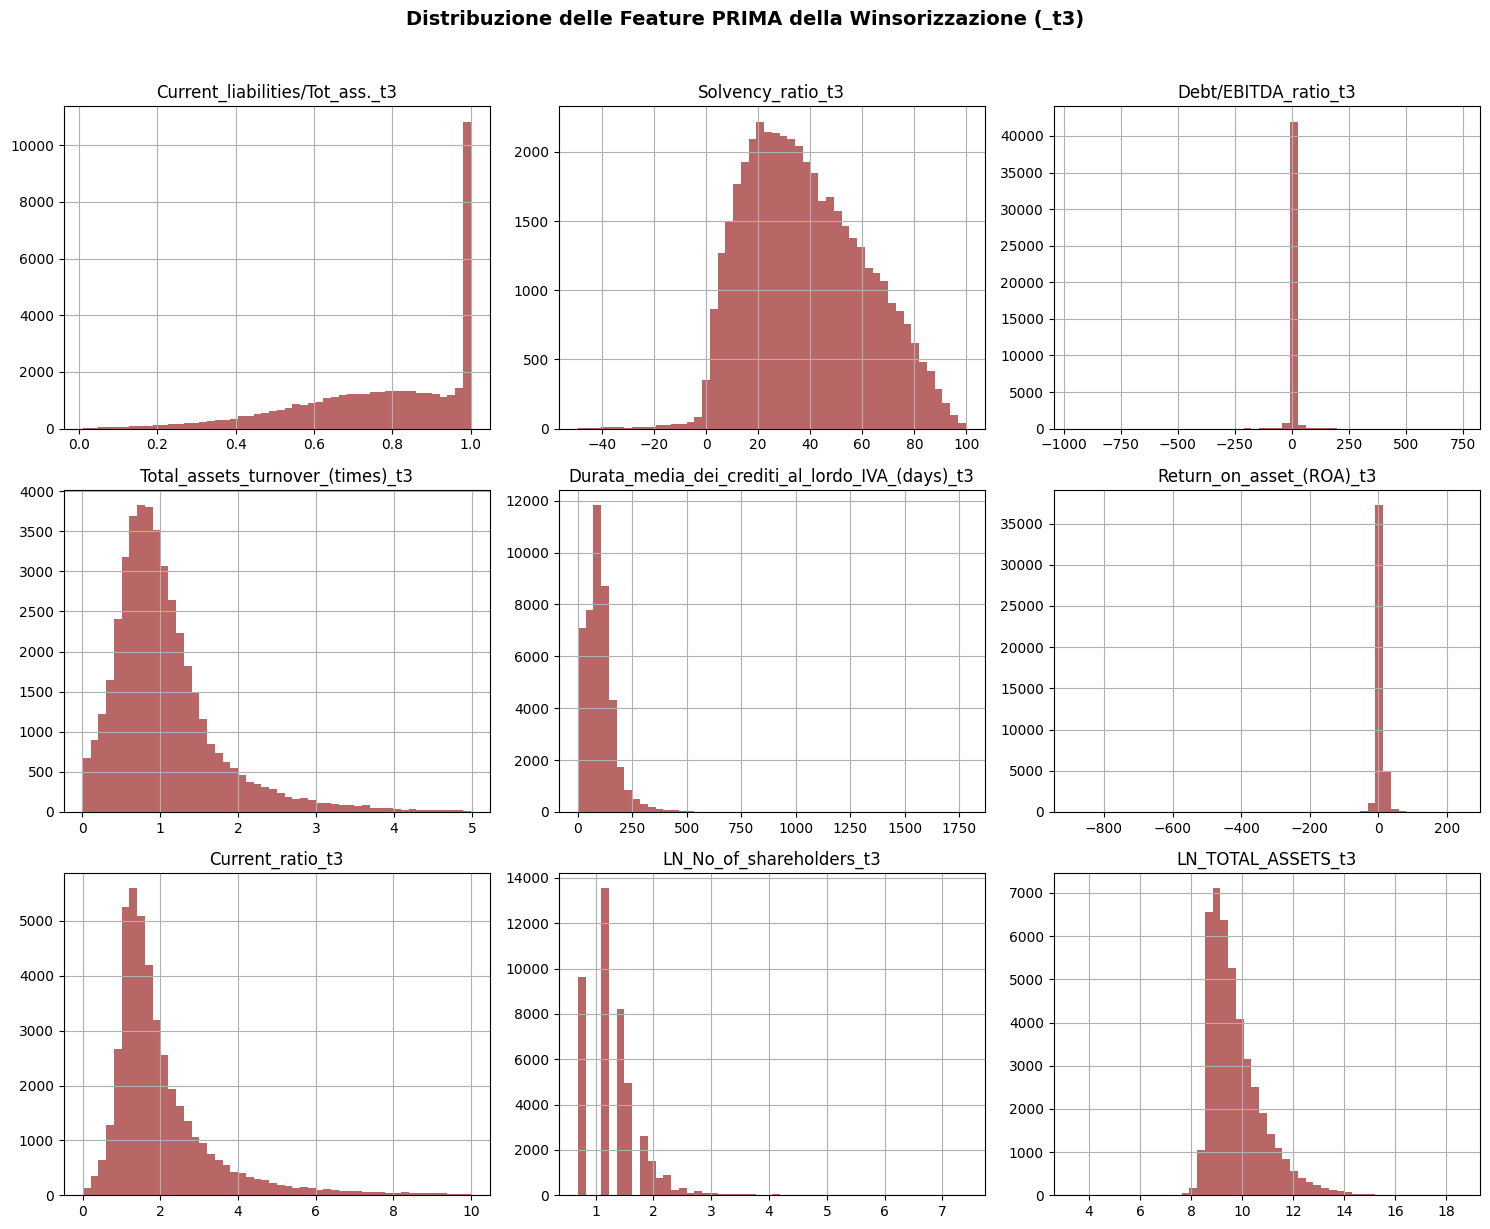



=== WINSORIZZAZIONE GLOBALE DEL PROFESSORE COMPLETATA CON SUCCESSO ===
-----------------------------------------------------------------
Generazione istogrammi DOPO la Winsorizzazione (Ex-Post)...


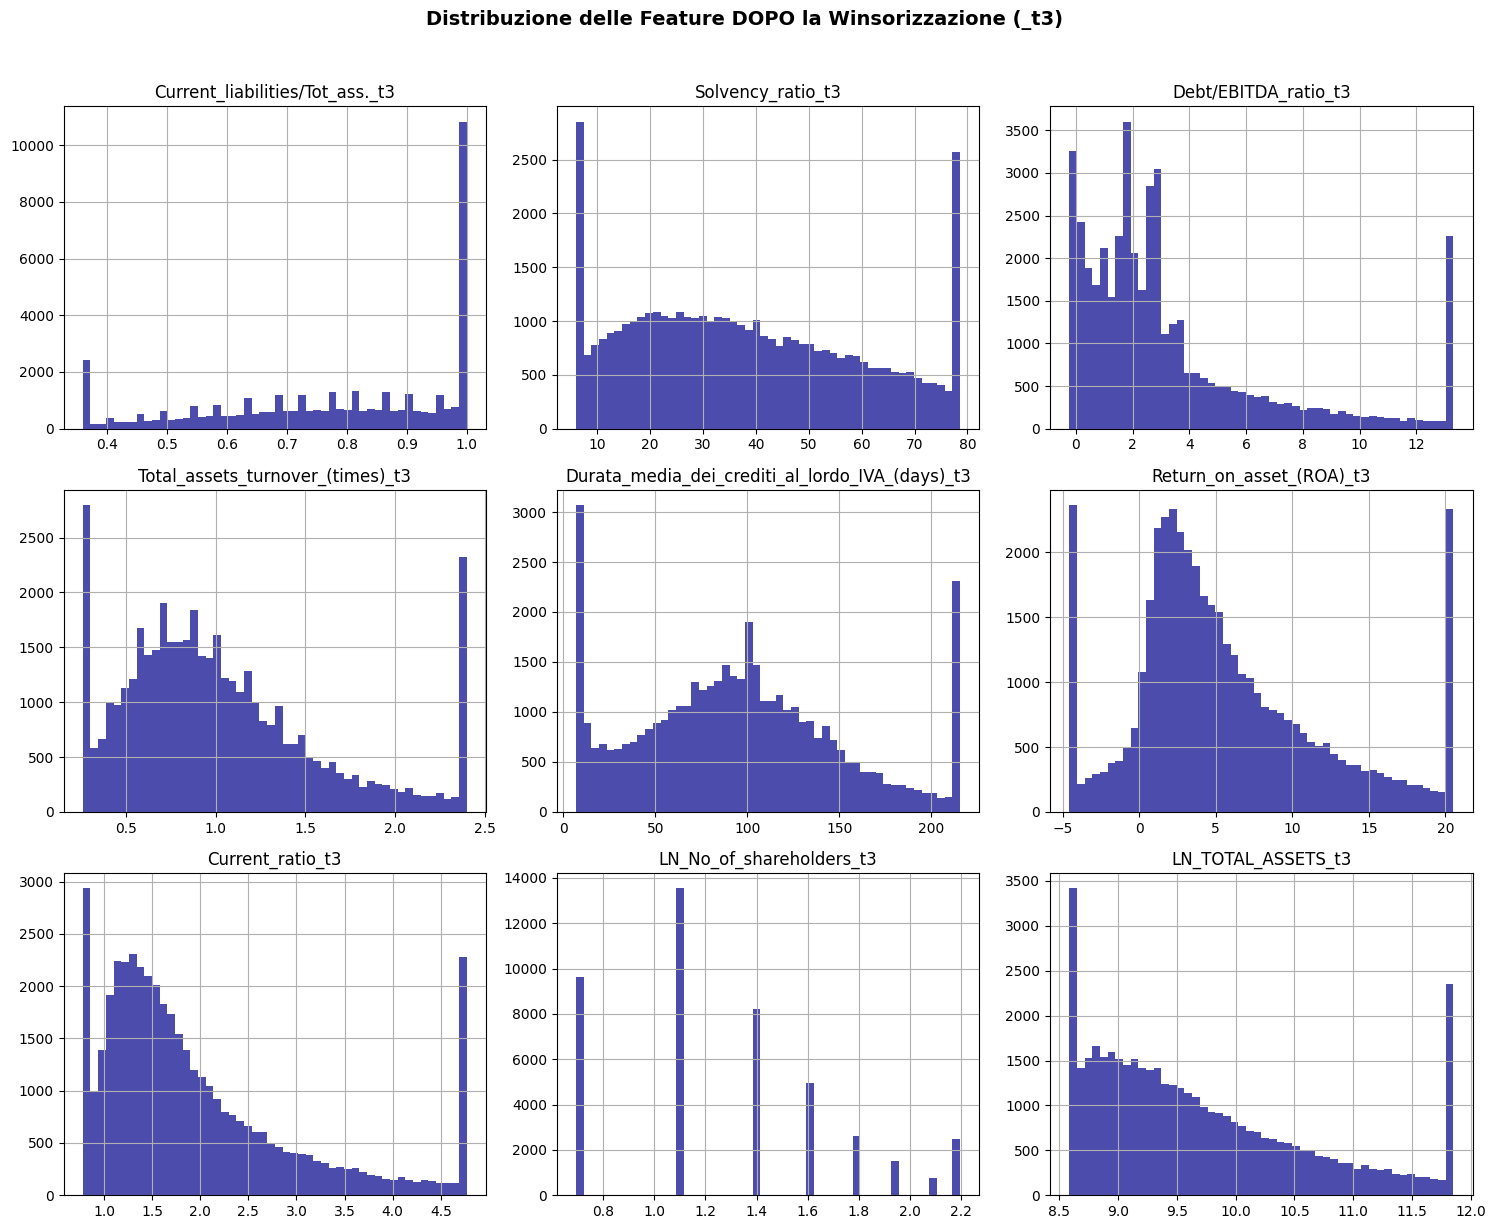


=== VERIFICA STRUTTURALE DEL DATASET DEFINITIVO (DF_FINAL_T3) ===
Numero totale di righe nel dataset: 43700
Numero totale di colonne nel dataset: 32

Distribuzione finale del Target (Verifica Specchio di ieri):
  - Aziende Sane (0):      43055
  - Aziende in Default (1): 645
  - TOTALE CAMPIONE:       43700


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

# Creiamo il dataset definitivo partendo da quello imputato
df_final_t3 = df_imputed.copy()

# Definizione delle sole variabili numeriche da sottoporre a winsorizzazione
selected_variables = [
    'Current_liabilities/Tot_ass._t3',
    'Solvency_ratio_t3',
    'Debt/EBITDA_ratio_t3',
    'Total_assets_turnover_(times)_t3',
    'Durata_media_dei_crediti_al_lordo_IVA_(days)_t3',
    'Return_on_asset_(ROA)_t3',
    'Current_ratio_t3',
    'LN_No_of_shareholders_t3',
    'LN_TOTAL_ASSETS_t3'
]

# Filtro di sicurezza per includere solo le colonne realmente presenti
selected_variables = [col for col in selected_variables if col in df_final_t3.columns]

print(f"Variabili pronte per il trattamento degli outlier: {len(selected_variables)}")
print("-" * 65)

# PLOT DISTRIBUZIONE PRIMA DELLA WINSORIZZAZIONE (Dati Imputati)
print("Generazione istogrammi PRIMA della Winsorizzazione (Ex-Ante)...")
df_imputed[selected_variables].hist(figsize=(15, 12), bins=50, color='darkred', alpha=0.6)
plt.suptitle('Distribuzione delle Feature PRIMA della Winsorizzazione (_t3)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")

# ESECUZIONE WINSORIZZAZIONE SIMMETRICA AL 5%
# Applichiamo la winsorizzazione colonna per colonna tagliando il 5% alle code (inf e sup)
df_final_t3[selected_variables] = df_final_t3[selected_variables].apply(lambda x: winsorize(x, limits=[0.05, 0.05]))

print("=== WINSORIZZAZIONE GLOBALE DEL PROFESSORE COMPLETATA CON SUCCESSO ===")
print("-" * 65)

# PLOT DISTRIBUZIONE DOPO LA WINSORIZZAZIONE (Dati Definitivi)
print("Generazione istogrammi DOPO la Winsorizzazione (Ex-Post)...")
df_final_t3[selected_variables].hist(figsize=(15, 12), bins=50, color='darkblue', alpha=0.7)
plt.suptitle('Distribuzione delle Feature DOPO la Winsorizzazione (_t3)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# DIAGNOSTICA DI CONTROLLO DELLE OSSERVAZIONI PRESERVATE
print("\n" + "="*80)
print("=== VERIFICA STRUTTURALE DEL DATASET DEFINITIVO (DF_FINAL_T3) ===")
print("="*80)
print(f"Numero totale di righe nel dataset: {df_final_t3.shape[0]}")
print(f"Numero totale di colonne nel dataset: {df_final_t3.shape[1]}")
print("\nDistribuzione finale del Target:")
conteggio_target = df_final_t3['Target'].value_counts()
print(f"  - Aziende Sane (0):      {conteggio_target.get(0, 0)}")
print(f"  - Aziende in Default (1): {conteggio_target.get(1, 0)}")
print(f"  - TOTALE CAMPIONE:       {df_final_t3.shape[0]}")


--- MATRICE DI CORRELAZIONE TABELLARE CORRETTA (_t3) ---


,Current_liabilities/Tot_ass._t3,Solvency_ratio_t3,Debt/EBITDA_ratio_t3,Total_assets_turnover_(times)_t3,Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,Return_on_asset_(ROA)_t3,Current_ratio_t3,LN_No_of_shareholders_t3,LN_TOTAL_ASSETS_t3
Current_liabilities/Tot_ass._t3,1.00,0.18,-0.28,0.30,0.03,0.22,-0.04,-0.09,-0.03
Solvency_ratio_t3,0.18,1.00,-0.31,-0.23,-0.09,0.33,0.64,0.06,0.12
Debt/EBITDA_ratio_t3,-0.28,-0.31,1.00,-0.03,0.06,-0.32,-0.18,0.05,-0.00
Total_assets_turnover_(times)_t3,0.30,-0.23,-0.03,1.00,-0.26,0.23,-0.16,-0.08,-0.18
Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,0.03,-0.09,0.06,-0.26,1.00,-0.06,0.03,0.04,-0.14
Return_on_asset_(ROA)_t3,0.22,0.33,-0.32,0.23,-0.06,1.00,0.29,-0.04,-0.09
Current_ratio_t3,-0.04,0.64,-0.18,-0.16,0.03,0.29,1.00,0.02,-0.05
LN_No_of_shareholders_t3,-0.09,0.06,0.05,-0.08,0.04,-0.04,0.02,1.00,0.02
LN_TOTAL_ASSETS_t3,-0.03,0.12,-0.00,-0.18,-0.14,-0.09,-0.05,0.02,1.00


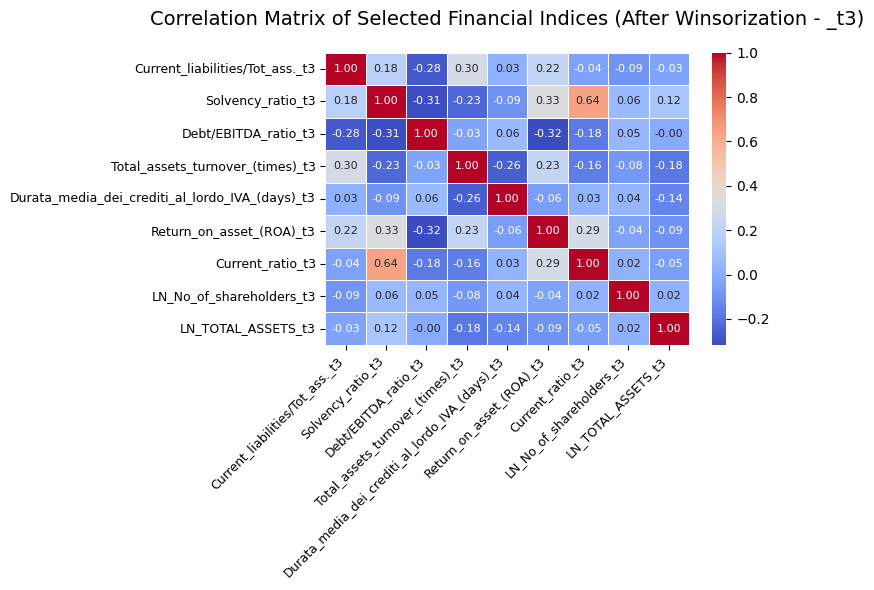

In [ ]:
import seaborn as sns

# MATRICE DI CORRELAZIONE E HEATMAP OTTIMIZZATA (_t3)

# Calcoliamo la matrice di correlazione di Pearson sulle variabili selezionate e winsorizzate
correlation_matrix = df_final_t3[selected_variables].corr()

print("\n--- MATRICE DI CORRELAZIONE TABELLARE CORRETTA (_t3) ---")
display(correlation_matrix.round(2))

# Visualizzazione grafica della Heatmap con Seaborn
plt.figure(figsize=(8, 6))

# Nota: annot_kws={"size": 8} rimpicciolisce i numeri dentro i quadranti
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8}
)

# OTTIMIZZAZIONE SPAZI E INCLINAZIONE SCRITTE
# Rimpiccioliamo e incliniamo le scritte sull'asse X
plt.xticks(rotation=45, ha='right', fontsize=9)

# Rimpiccioliamo le scritte sull'asse Y
plt.yticks(fontsize=9)

plt.title('Correlation Matrix of Selected Financial Indices (After Winsorization - _t3)', fontsize=14, pad=20)

# Nota: tight_layout aiuta a non tagliare le scritte inclinate ai margini del foglio
plt.tight_layout()
plt.show()

In [ ]:
# SELEZIONE FEATURE E GENERAZIONE MATRICI DA DF_FINAL_T3

final_features = [
    'LN_TOTAL_ASSETS_t3',
    'Current_liabilities/Tot_ass._t3',
    'Solvency_ratio_t3',
    'Debt/EBITDA_ratio_t3',
    'Total_assets_turnover_(times)_t3',
    'Durata_media_dei_crediti_al_lordo_IVA_(days)_t3',
    'Return_on_asset_(ROA)_t3',
    'Current_ratio_t3',
    'LN_No_of_shareholders_t3',
    'Independence_t3_B',
    'Independence_t3_C',
    'Independence_t3_D',
    'Independence_t3_Missing',
    'Area_Center',  # Controllo Geografico Centro
    'Area_South'    # Controllo Geografico Sud (Nord omesso come riferimento)
]

# Estraiamo le matrici puntando su df_final_t3 (che ha subito l'imputazione ed ha zero NaN)
df_model_ready = df_final_t3.dropna(subset=final_features + ['Target'])

X = df_model_ready[final_features]
y = df_model_ready['Target']

print("=== DATASET PRONTO PER LA REGRESSIONE LOGISTICA ===")
print(f"Numero totale di osservazioni nel campione: {X.shape[0]}")
print(f"Numero totale di variabili esplicative (Feature): {X.shape[1]}")
print(f"Distribuzione del Target verificata:")
print(y.value_counts())
print("-" * 75)

# Salvataggio del dataset finale in formato CSV
df_to_save = pd.concat([X, y], axis=1)
output_path_personalizzato = "/content/drive/MyDrive/italian_firms_cleaned_t3.csv"
df_to_save.to_csv(output_path_personalizzato, index=False)

print(f"=== SALVATAGGIO COMPLETATO CON SUCCESSO ===")
print(f"Il file con la geografia e la governance è depositato in: {output_path_personalizzato}")
print(f"Dimensioni specchio: {df_to_save.shape[0]} righe e {df_to_save.shape[1]} colonne.")

=== DATASET PRONTO PER LA REGRESSIONE LOGISTICA ===
Numero totale di osservazioni nel campione: 43700
Numero totale di variabili esplicative (Feature): 15
Distribuzione del Target verificata:
Target
0    43055
1      645
Name: count, dtype: int64
---------------------------------------------------------------------------
=== SALVATAGGIO COMPLETATO CON SUCCESSO ===
Il file con la geografia e la governance è depositato in: /content/drive/MyDrive/italian_firms_cleaned_t3.csv
Dimensioni specchio: 43700 righe e 16 colonne.


In [ ]:
display(X)

,LN_TOTAL_ASSETS_t3,Current_liabilities/Tot_ass._t3,Solvency_ratio_t3,Debt/EBITDA_ratio_t3,Total_assets_turnover_(times)_t3,Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,Return_on_asset_(ROA)_t3,Current_ratio_t3,LN_No_of_shareholders_t3,Independence_t3_B,Independence_t3_C,Independence_t3_D,Independence_t3_Missing,Area_Center,Area_South
0,11.851504,1.00,5.98,13.30,0.49,26.76,0.25,1.00,0.693147,0,0,1,0,1,0
1,11.851504,0.45,49.99,13.30,0.34,20.74,-2.45,1.59,2.197225,1,0,0,0,1,0
2,11.851504,1.00,28.33,0.09,2.40,41.06,20.52,1.17,1.098612,0,0,1,0,1,0
3,11.851504,0.52,32.65,-0.23,0.84,7.01,-4.57,1.75,0.693147,0,1,0,0,0,0
4,11.851504,0.93,16.29,1.04,2.40,20.01,4.77,0.82,0.693147,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44379,8.620779,1.00,23.36,13.30,1.28,67.25,1.21,1.13,1.386294,1,0,0,0,0,1
44381,9.710448,0.36,5.98,1.93,0.84,61.91,-4.57,4.77,1.098612,0,0,1,0,0,1
44382,9.468268,0.88,33.69,-0.23,1.09,99.00,-4.57,0.78,1.098612,0,0,0,1,0,1
44384,8.923721,0.62,7.46,13.30,0.55,7.01,1.46,1.19,1.098612,0,0,1,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# 1. Suddivisione del campione corretta (70% Train, 30% Test)
# Usiamo il parametro esatto: random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("=== RIGORE METODOLOGICO: SUDDIVISIONE DEL CAMPIONE ===")
print(f"Aziende totali nel Training Set (70%): {X_train.shape[0]} (di cui default reali: {y_train.sum()})")
print(f"Aziende totali nel Test Set (30%): {X_test.shape[0]} (di cui default reali: {y_test.sum()})")
print("-" * 60)

# Convertiamo esplicitamente X_train in float per evitare qualsiasi attrito con statsmodels
X_train = X_train.astype(float)

# 2. Aggiungiamo la costante (Intercetta alpha) alla matrice X di addestramento
X_train_with_const = sm.add_constant(X_train)

# 3. Lancio della Regressione Logistica sul Training Set
model = sm.Logit(y_train, X_train_with_const)
results = model.fit()

# 4. Visualizzazione della Tabella dei Risultati
print("\n=== OUTPUT DELLA REGRESSIONE LOGISTICA (TRAINING SET) ===")
print(results.summary())

=== RIGORE METODOLOGICO: SUDDIVISIONE DEL CAMPIONE ===
Aziende totali nel Training Set (70%): 30590 (di cui default reali: 452)
Aziende totali nel Test Set (30%): 13110 (di cui default reali: 193)
------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.032997
         Iterations 12

=== OUTPUT DELLA REGRESSIONE LOGISTICA (TRAINING SET) ===
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                30590
Model:                          Logit   Df Residuals:                    30574
Method:                           MLE   Df Model:                           15
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                  0.5712
Time:                        09:52:54   Log-Likelihood:                -1009.4
converged:                       True   LL-Null:                       -2353.7
Covariance Type:           